# Create multi-simulation dataset with ABSORBING outflow ghost cells
Notebook twin of `build_template_outflow_gc.py` + `run_convert_multisim_outflow.py`.

Builds the outflow ghost-cell template, converts the 1.0x + 4 scaled
simulations onto it, and merges the 4 scaled events into one training pkl:

    train/ahr_..._warmstart_outflow_gc_multisim.pkl                 (4 events, training)
    train+test/ahr_..._warmstart_outflow_gc.pkl                     (1.0x, validation/test)
    train+test/ahr_..._warmstart_{q050,q075,q125,q150}_outflow_gc.pkl (per factor)

Train with `config_best_sweep_multisim_msloss_outflow.yaml`.

In [3]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Config

In [3]:
TEMPLATE_PKL = 'database/datasets/train/template_100m_outflow_gc.pkl'

# template sources (same as build_template_outflow_gc.py)
SFINCS_DIR_TEMPLATE = ('database/raw_datasets_ahr/Simulations/'
                       'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon')

SIM_ROOT    = 'database/raw_datasets_ahr/Simulations'
BASE_FOLDER = 'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart'

# tag -> (sim folder, output dataset name)
SIMS = {
    '1x':   (BASE_FOLDER,           'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_outflow_gc'),
    'q050': (BASE_FOLDER + '_q050', 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q050_outflow_gc'),
    'q075': (BASE_FOLDER + '_q075', 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q075_outflow_gc'),
    'q125': (BASE_FOLDER + '_q125', 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q125_outflow_gc'),
    'q150': (BASE_FOLDER + '_q150', 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q150_outflow_gc'),
}
MERGED_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_outflow_gc_multisim'

OUT_ROOT = 'database/datasets'

FORCE_REBUILD_TEMPLATE = False  # auto-forced anyway if the template has the OLD one-way edges
FORCE_REBUILD_PKL      = False  # True to reconvert even if the per-sim pkl exists

for tag, (folder, _) in SIMS.items():
    sim_dir = os.path.join(SIM_ROOT, folder)
    ok = all(os.path.exists(os.path.join(sim_dir, f)) for f in ['sfincs_map.nc', 'sfincs.src', 'sfincs.dis'])
    print(f"{tag}: {'OK' if ok else 'MISSING FILES'}  {sim_dir}")

1x: OK  database/raw_datasets_ahr/Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart
q050: OK  database/raw_datasets_ahr/Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart_q050
q075: OK  database/raw_datasets_ahr/Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart_q075
q125: OK  database/raw_datasets_ahr/Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart_q125
q150: OK  database/raw_datasets_ahr/Simulations\ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart_q150


## Step 1 — Ghost-cell template (rebuild if missing OR if it still has one-way edges)
The absorbing outflow requires ghost edges in BOTH directions (graph_creation.py fix, Jul 2026).
A template built before the fix has ghosts only as edge DESTINATIONS — detected and rebuilt here.

In [ ]:
import pickle
import torch
from database.create_mesh_template_marg import create_mesh_template_pkl
from database.convert_sfincs_to_pkl_marg import load_single_data_object

def template_has_bidirectional_ghosts(path):
    '''True if at least one edge STARTS at an outflow ghost cell (ghost -> interior).'''
    data = load_single_data_object(path)
    if not hasattr(data, 'node_BC_outflow') or len(data.node_BC_outflow) == 0:
        return False
    ghosts = data.node_BC_outflow.to(torch.long)
    return bool(torch.isin(data.edge_index[0], ghosts).any())

rebuild = FORCE_REBUILD_TEMPLATE or not os.path.exists(TEMPLATE_PKL)
if not rebuild:
    if template_has_bidirectional_ghosts(TEMPLATE_PKL):
        print('Template OK (bidirectional ghost edges):', TEMPLATE_PKL)
    else:
        print('Template has the OLD one-way ghost edges -> rebuilding')
        rebuild = True

if rebuild:
    if os.path.exists(TEMPLATE_PKL):
        os.remove(TEMPLATE_PKL)
    create_mesh_template_pkl(
        shapefile_path        = os.path.join(SFINCS_DIR_TEMPLATE, 'gis', 'region.geojson'),
        dem_tif_path          = os.path.join(SFINCS_DIR_TEMPLATE, 'gis', 'dep.tif'),
        output_pkl_path       = TEMPLATE_PKL,
        with_multiscale       = True,
        number_of_multiscales = 4,
        mesh_resolutions      = [2000, 1000, 500],
        sfincs_map_nc         = os.path.join(SFINCS_DIR_TEMPLATE, 'sfincs_map.nc'),
    )
    print('Template created:', TEMPLATE_PKL)
    assert template_has_bidirectional_ghosts(TEMPLATE_PKL), \
        'rebuilt template still one-way?! check database/graph_creation.py (undirected_BC=True)'
    print('Bidirectional ghost edges verified.')

Template OK (bidirectional ghost edges): database/datasets/train/template_100m_outflow_gc.pkl


: 

In [4]:
import pickle
import torch
import matplotlib.pyplot as plt
from database.create_mesh_template_marg import create_mesh_template_pkl
from database.convert_sfincs_to_pkl_marg import load_single_data_object
# TEMPLATE_PKL = 'database/datasets/train/template_100m.pkl'

# mesh_load = load_single_data_object(TEMPLATE_PKL)
# full = mesh_load.mesh          # combined multiscale mesh — same indexing as node_BC
# finest = mesh_load.mesh.meshes[0]  # finest scale only, LOCAL indices

# plt.scatter(finest.face_x, finest.face_y)                       # background: finest mesh cells
# plt.scatter(full.face_x[mesh_load.node_BC], full.face_y[mesh_load.node_BC],
#             color='red', s=100, zorder=5)                        # node_BC, correctly indexed


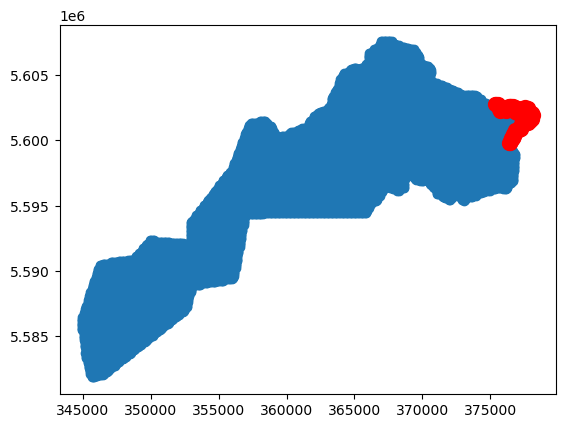

: 

In [ ]:
TEMPLATE_PKL1 = 'database/datasets/train/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_outflow_gc_multisim.pkl'

mesh_load = load_single_data_object(TEMPLATE_PKL1)
full = mesh_load.mesh          # combined multiscale mesh — same indexing as node_BC
finest = mesh_load.mesh.meshes[0]  # finest scale only, LOCAL indices

plt.scatter(finest.face_x, finest.face_y)
plt.scatter(finest.face_x[mesh_load.node_BC_outflow], finest.face_y[mesh_load.node_BC_outflow],
            color='red', s=100, zorder=5)                       # node_BC, correctly indexed


## Step 2 — Convert the 5 simulations onto the gc template
(same conversion as run_convert_warmstart_inflow_outflow_gc.py, looped; each dataset
carries node_BC_outflow so the absorbing clamp activates automatically in training)

In [5]:
import copy
import numpy as np
import xarray as xr
from scipy.interpolate import griddata

from database.convert_sfincs_to_pkl_marg import (
    get_target_points, build_output_data, parse_src_file, parse_dis_file,
)

print('Loading gc template...')
template_data = load_single_data_object(TEMPLATE_PKL)
target_points = get_target_points(template_data)
num_targets   = target_points.shape[0]
assert hasattr(template_data, 'node_BC_outflow'), 'template has no node_BC_outflow!'
print(f'  Target mesh faces: {num_targets}')
print(f'  Outflow ghost cells: {len(template_data.node_BC_outflow)}')


def convert_one(sim_dir):
    '''SFINCS map -> Data object on the gc template.'''
    sfincs_map = os.path.join(sim_dir, 'sfincs_map.nc')
    ds  = xr.open_dataset(sfincs_map, decode_times=False)
    msk = ds['msk'].values
    zs  = ds['zs'].values
    zb  = ds['zb'].values
    if msk.ndim == 1:
        msk = msk.reshape(zs.shape[1], zs.shape[2])

    x = ds.coords['x'].values
    y = ds.coords['y'].values
    if x.ndim == 1 and y.ndim == 1:
        if len(x) == msk.shape[1] and len(y) == msk.shape[0]:
            x, y = np.meshgrid(x, y, indexing='xy')
        elif x.shape[0] == msk.size:
            x = x.reshape(msk.shape)
            y = y.reshape(msk.shape)

    active        = msk > 0
    source_points = np.column_stack([x[active], y[active]])
    time_var      = ds.coords.get('time', ds.coords.get('t', None))
    map_times_s   = time_var.values.astype(np.float64) if time_var is not None \
                    else np.arange(zs.shape[0]) * 3600.0
    time_steps    = zs.shape[0]

    # WD (NaN = dry -> fill with bed level so it enters as WD=0)
    zs_active = zs[:, active]
    zb_active = zb[active]
    zs_filled = np.where(np.isnan(zs_active), zb_active[None, :], zs_active)
    WD_active = np.maximum(zs_filled - zb_active[None, :], 0.0).astype(np.float32)
    WD = np.zeros((num_targets, time_steps), dtype=np.float32)
    for t in range(time_steps):
        iv = griddata(source_points, WD_active[t], target_points, method='linear')
        WD[:, t] = np.nan_to_num(iv, nan=0.0)
    del WD_active, zs_active, zs_filled

    # Velocities
    ds_raw = xr.open_dataset(sfincs_map, decode_times=False, mask_and_scale=False)
    VX = np.zeros((num_targets, time_steps), dtype=np.float32)
    VY = np.zeros((num_targets, time_steps), dtype=np.float32)
    for var, arr_out in [('u', VX), ('v', VY)]:
        if var in ds_raw.data_vars:
            raw = ds_raw[var].values.astype(np.float32)
            fv  = ds_raw[var].attrs.get('_FillValue', None)
            if fv is not None:
                raw[raw == float(fv)] = np.nan
            act = raw[:, active]
            del raw
            for t in range(time_steps):
                ok = np.isfinite(act[t])
                if ok.sum() > 3:
                    iv = griddata(source_points[ok], act[t][ok], target_points, method='linear')
                    arr_out[:, t] = np.nan_to_num(iv, nan=0.0)
            del act
    ds_raw.close()

    # Discharge BC (type_BC=2)
    src_xy = parse_src_file(os.path.join(sim_dir, 'sfincs.src'))
    dis_times_s, discharge = parse_dis_file(os.path.join(sim_dir, 'sfincs.dis'))
    del zs, zb
    ds.close()

    data_out = build_output_data(template_data, WD=WD, VX=VX, VY=VY,
                                 map_times_s=map_times_s,
                                 src_xy=src_xy, dis_times_s=dis_times_s, discharge=discharge)
    data_out.node_BC_outflow = template_data.node_BC_outflow
    return data_out


per_sim = {}
for tag, (folder, dataset_name) in SIMS.items():
    sim_dir = os.path.join(SIM_ROOT, folder)
    out_train = os.path.join(OUT_ROOT, 'train', dataset_name + '.pkl')
    if not FORCE_REBUILD_PKL and os.path.exists(out_train):
        print(f'{tag}: already converted, loading ({dataset_name})')
        with open(out_train, 'rb') as f:
            per_sim[tag] = pickle.load(f)[0]
        continue

    print(f'\n=== converting {tag} ({folder}) ===')
    data_out = convert_one(sim_dir)
    per_sim[tag] = data_out
    print(f'  WD={tuple(data_out.WD.shape)}  Q peak={float(data_out.BC[:,:,1].max()):.1f} m3/s  '
          f'type_BC={int(data_out.type_BC)}  outflow gc={len(data_out.node_BC_outflow)}')
    for split in ('train', 'test'):
        os.makedirs(os.path.join(OUT_ROOT, split), exist_ok=True)
        with open(os.path.join(OUT_ROOT, split, dataset_name + '.pkl'), 'wb') as f:
            pickle.dump([copy.deepcopy(data_out)], f)
    print(f'  saved train+test: {dataset_name}.pkl')

Loading gc template...
  Target mesh faces: 30079
  Outflow ghost cells: 87
1x: already converted, loading (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_outflow_gc)
q050: already converted, loading (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q050_outflow_gc)
q075: already converted, loading (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q075_outflow_gc)
q125: already converted, loading (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q125_outflow_gc)
q150: already converted, loading (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q150_outflow_gc)


## Step 3 — Merge the 4 scaled events into one training pkl
The 1.0x event stays OUT (it is the validation/test dataset).
Sanity: Q-peak ratios ~0.5 / 0.75 / 1.25 / 1.5 and node_BC identical everywhere.

In [ ]:
q_ref = float(per_sim['1x'].BC[:, :, 1].max())
node_bc_ref = per_sim['1x'].node_BC.tolist()
print(f'1.0x reference: Q peak = {q_ref:.1f} m3/s   node_BC = {node_bc_ref}')
print()

merged = []
for tag in ['q050', 'q075', 'q125', 'q150']:
    d = per_sim[tag]
    q = float(d.BC[:, :, 1].max())
    same_bc = d.node_BC.tolist() == node_bc_ref
    print(f'{tag}: Q peak = {q:8.1f} m3/s (ratio {q/q_ref:.3f})   '
          f'WD peak = {float(d.WD.max()):.3f} m   node_BC identical: {same_bc}')
    assert same_bc, f'{tag}: node_BC differs from the 1.0x event!'
    merged.append(d)

out_path = os.path.join(OUT_ROOT, 'train', MERGED_NAME + '.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(merged, f)
print(f'\nSaved {len(merged)} events -> {out_path}')
print('Train with config_best_sweep_multisim_msloss_outflow.yaml.')

1.0x reference: Q peak = 450.0 m3/s   node_BC = [12555, 7287, 15, 368, 5453, 3676, 6427]

q050: Q peak =    225.0 m3/s (ratio 0.500)   WD peak = 8.222 m   node_BC identical: True
q075: Q peak =    337.5 m3/s (ratio 0.750)   WD peak = 9.489 m   node_BC identical: True
q125: Q peak =    562.5 m3/s (ratio 1.250)   WD peak = 11.974 m   node_BC identical: True
q150: Q peak =    675.0 m3/s (ratio 1.500)   WD peak = 16.623 m   node_BC identical: True

Saved 4 events -> database/datasets\train\ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_outflow_gc_multisim.pkl
Train with config_best_sweep_multisim_msloss_outflow.yaml.


: 